<a href="https://colab.research.google.com/github/dystaSatria/Deep-Learning/blob/main/Internship%20Projects/Kalkulus%20ve%20Zincir%20Kural%C4%B1/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

KALKULus VE SİNİR AĞLARI ÖRNEĞİ
=== TÜREVLERİN TEST EDİLMESİ ===


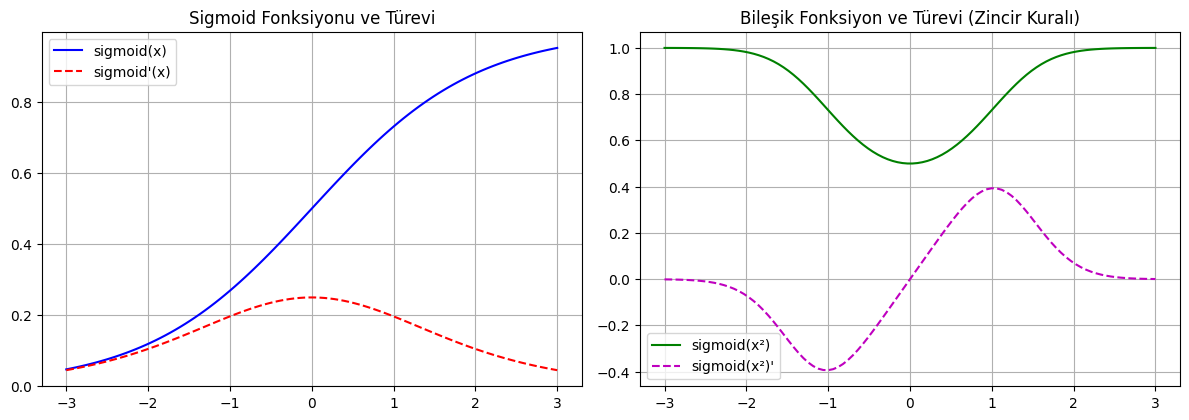


Sayısal örnekler:
x = -1:
  sigmoid(-1) = 0.2689
  sigmoid'(-1) = 0.1966
  sigmoid(x²) = 0.7311
  sigmoid(x²)' = -0.3932

x = 0:
  sigmoid(0) = 0.5000
  sigmoid'(0) = 0.2500
  sigmoid(x²) = 0.5000
  sigmoid(x²)' = 0.0000

x = 1:
  sigmoid(1) = 0.7311
  sigmoid'(1) = 0.1966
  sigmoid(x²) = 0.7311
  sigmoid(x²)' = 0.3932

x = 2:
  sigmoid(2) = 0.8808
  sigmoid'(2) = 0.1050
  sigmoid(x²) = 0.9820
  sigmoid(x²)' = 0.0707


=== SİNİR AĞI ÖĞRENME TESTİ ===
Epoch 0, Kayıp: 0.272986
Epoch 200, Kayıp: 0.255430
Epoch 400, Kayıp: 0.252472
Epoch 600, Kayıp: 0.250504
Epoch 800, Kayıp: 0.248714

Son tahminler:
Giriş: [0 0], Hedef: 0, Tahmin: 0.4577
Giriş: [0 1], Hedef: 1, Tahmin: 0.5233
Giriş: [1 0], Hedef: 1, Tahmin: 0.4973
Giriş: [1 1], Hedef: 0, Tahmin: 0.5448

=== AÇIKLAMA ===
Bu örnekte:
1. Sigmoid fonksiyonu ve türevi hesaplandı
2. Zincir kuralı ile bileşik fonksiyon türevi bulundu
3. Basit bir sinir ağında zincir kuralı kullanıldı
4. Geri yayılım algoritmasında türevler otomatik güncelleme i

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Basit fonksiyonlar ve türevleri
def sigmoid(x):
    """Sigmoid aktivasyon fonksiyonu"""
    return 1 / (1 + np.exp(-x))

def sigmoid_turev(x):
    """Sigmoid fonksiyonunun türevi"""
    s = sigmoid(x)
    return s * (1 - s)

def kare_fonksiyon(x):
    """Basit kare fonksiyonu: f(x) = x^2"""
    return x ** 2

def kare_turev(x):
    """Kare fonksiyonunun türevi: f'(x) = 2x"""
    return 2 * x

# Zincir kuralı örneği
def birlesik_fonksiyon(x):
    """Bileşik fonksiyon: f(g(x)) = sigmoid(x^2)"""
    return sigmoid(kare_fonksiyon(x))

def birlesik_fonksiyon_turev(x):
    """Zincir kuralı ile türev: f'(g(x)) * g'(x)"""
    # Dış fonksiyon türevi: sigmoid'(x^2)
    dis_turev = sigmoid_turev(kare_fonksiyon(x))
    # İç fonksiyon türevi: (x^2)' = 2x
    ic_turev = kare_turev(x)
    # Zincir kuralı: dış_türev * iç_türev
    return dis_turev * ic_turev

# Basit sinir ağı örneği
class BasitSinirAgi:
    def __init__(self):
        # Rastgele ağırlıklar
        self.w1 = np.random.randn(2, 3)  # Giriş -> Gizli katman
        self.w2 = np.random.randn(3, 1)  # Gizli -> Çıkış katman
        self.ogrenme_orani = 0.1

    def ileri_gecis(self, X):
        """İleri geçiş (Forward pass)"""
        # Gizli katman
        self.z1 = np.dot(X, self.w1)
        self.a1 = sigmoid(self.z1)

        # Çıkış katmanı
        self.z2 = np.dot(self.a1, self.w2)
        self.a2 = sigmoid(self.z2)

        return self.a2

    def geri_gecis(self, X, y, cikis):
        """Geri geçiş (Backward pass) - Zincir kuralı kullanımı"""
        # Çıkış katmanı hatası
        cikis_hatasi = y - cikis
        cikis_delta = cikis_hatasi * sigmoid_turev(self.z2)

        # Gizli katman hatası (zincir kuralı)
        gizli_hata = cikis_delta.dot(self.w2.T)
        gizli_delta = gizli_hata * sigmoid_turev(self.z1)

        # Ağırlıkları güncelle
        self.w2 += self.a1.T.dot(cikis_delta) * self.ogrenme_orani
        self.w1 += X.T.dot(gizli_delta) * self.ogrenme_orani

# Test ve görselleştirme
def test_turev_ornekleri():
    """Türev örneklerini test et"""
    print("=== TÜREVLERİN TEST EDİLMESİ ===")

    x_degerler = np.linspace(-3, 3, 100)

    # Sigmoid ve türevi
    y_sigmoid = sigmoid(x_degerler)
    y_sigmoid_turev = sigmoid_turev(x_degerler)

    # Bileşik fonksiyon ve türevi
    y_birlesik = birlesik_fonksiyon(x_degerler)
    y_birlesik_turev = birlesik_fonksiyon_turev(x_degerler)

    # Grafik çizimi
    plt.figure(figsize=(12, 8))

    # Subplot 1: Sigmoid
    plt.subplot(2, 2, 1)
    plt.plot(x_degerler, y_sigmoid, 'b-', label='sigmoid(x)')
    plt.plot(x_degerler, y_sigmoid_turev, 'r--', label="sigmoid'(x)")
    plt.title('Sigmoid Fonksiyonu ve Türevi')
    plt.legend()
    plt.grid(True)

    # Subplot 2: Bileşik fonksiyon
    plt.subplot(2, 2, 2)
    plt.plot(x_degerler, y_birlesik, 'g-', label='sigmoid(x²)')
    plt.plot(x_degerler, y_birlesik_turev, 'm--', label="sigmoid(x²)'")
    plt.title('Bileşik Fonksiyon ve Türevi (Zincir Kuralı)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Sayısal örnekler
    print("\nSayısal örnekler:")
    for x in [-1, 0, 1, 2]:
        print(f"x = {x}:")
        print(f"  sigmoid({x}) = {sigmoid(x):.4f}")
        print(f"  sigmoid'({x}) = {sigmoid_turev(x):.4f}")
        print(f"  sigmoid(x²) = {birlesik_fonksiyon(x):.4f}")
        print(f"  sigmoid(x²)' = {birlesik_fonksiyon_turev(x):.4f}")
        print()

def test_sinir_agi():
    """Basit sinir ağı testi"""
    print("=== SİNİR AĞI ÖĞRENME TESTİ ===")

    # XOR problemi (basitleştirilmiş)
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([[0], [1], [1], [0]])

    # Sinir ağını oluştur
    agi = BasitSinirAgi()

    # Öğrenme döngüsü
    for epoch in range(1000):
        # İleri geçiş
        cikis = agi.ileri_gecis(X)

        # Geri geçiş (zincir kuralı burada kullanılıyor!)
        agi.geri_gecis(X, y, cikis)

        # Her 200 epoch'ta kayıp yazdır
        if epoch % 200 == 0:
            kayip = np.mean(np.square(y - cikis))
            print(f"Epoch {epoch}, Kayıp: {kayip:.6f}")

    print("\nSon tahminler:")
    son_cikis = agi.ileri_gecis(X)
    for i in range(len(X)):
        print(f"Giriş: {X[i]}, Hedef: {y[i][0]}, Tahmin: {son_cikis[i][0]:.4f}")

if __name__ == "__main__":
    print("KALKULus VE SİNİR AĞLARI ÖRNEĞİ")
    print("=" * 40)

    # Türev örneklerini test et
    test_turev_ornekleri()

    print("\n" + "=" * 40)

    # Sinir ağı testini çalıştır
    test_sinir_agi()

    print("\n=== AÇIKLAMA ===")
    print("Bu örnekte:")
    print("1. Sigmoid fonksiyonu ve türevi hesaplandı")
    print("2. Zincir kuralı ile bileşik fonksiyon türevi bulundu")
    print("3. Basit bir sinir ağında zincir kuralı kullanıldı")
    print("4. Geri yayılım algoritmasında türevler otomatik güncelleme için kullanıldı")